# Digit Classification

### Overview
The Digit Classification project involves classifying handwritten digits (0-9) using the MNIST dataset. This classic dataset is used to demonstrate image classification techniques and neural networks. 

### Dataset
The MNIST dataset is available in the `sklearn.datasets` module. It contains 70,000 images of handwritten digits, each 28x28 pixels in size. The dataset is divided into 60,000 training images and 10,000 testing images. Each image is labeled with the digit it represents.

### Objectives

#### Data Exploration and Preprocessing:
- Load the MNIST dataset.
- Inspect the dataset for basic statistics and data distribution.
- Preprocess the data by normalizing the images and reshaping them for model input.

#### Exploratory Data Analysis (EDA):
- Visualize a few sample images from the dataset.
- Analyze the distribution of digits in the training and testing sets.
- Understand the structure of the dataset.

#### Model Building and Evaluation:
- Split the dataset into training and testing sets (if not already done).
- Build a digit classification model using algorithms like Logistic Regression, Support Vector Machine (SVM), or a Convolutional Neural Network (CNN).
- Evaluate the model's performance using accuracy, confusion matrix, and classification report.

#### Model Tuning:
- Fine-tune hyperparameters to enhance model performance.
- Use techniques like cross-validation to assess model stability and generalization.

### Methods and Tools

#### Libraries Used:
- `tensorflow` and `keras` for building and training neural networks.
- `numpy` and `pandas` for data manipulation.
- `matplotlib` and `seaborn` for data visualization.

#### Techniques:
- **Data Normalization:** Rescaling pixel values to a range of [0, 1] to improve model performance.
- **Model Building:** Using deep learning models, particularly Convolutional Neural Networks (CNNs) for image classification.
- **Model Evaluation:** Assessing the accuracy and performance of the trained model.

Feature names: ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7']
Target names: [0 1 2 3 4 5 6 7 8 9]
Number of samples: 1797
Number of features: 64
Sample data:
[[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15

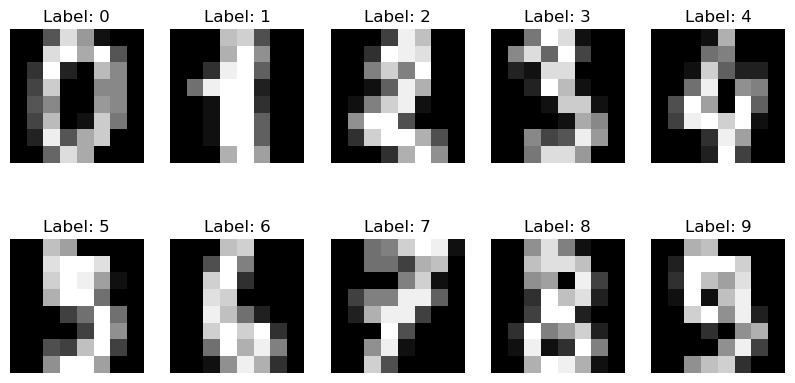


K-Nearest Neighbors Performance:
Accuracy: 0.98
Confusion Matrix:
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  1 46  0  0  0  0  0  0  0]
 [ 0  0  1 53  0  0  0  0  0  0]
 [ 0  0  0  0 60  0  0  0  0  0]
 [ 0  0  0  0  0 64  1  0  0  1]
 [ 0  0  0  0  0  0 53  0  0  0]
 [ 0  0  0  0  0  1  0 53  0  1]
 [ 0  0  0  1  0  0  0  0 42  0]
 [ 0  0  0  2  1  1  1  0  1 53]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.98      1.00      0.99        50
           2       0.98      0.98      0.98        47
           3       0.95      0.98      0.96        54
           4       0.98      1.00      0.99        60
           5       0.97      0.97      0.97        66
           6       0.96      1.00      0.98        53
           7       1.00      0.96      0.98        55
           8       0.98      0.98      0.98        43
           9       0.96      0.90     

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the Digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Inspect the dataset
print(f'Feature names: {digits.feature_names}')
print(f'Target names: {digits.target_names}')
print(f'Number of samples: {len(X)}')
print(f'Number of features: {X.shape[1]}')
print(f'Sample data:\n{X[:5]}')
print(f'Sample labels:\n{y[:5]}')

# Visualize some sample images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X[i].reshape(8, 8), cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.show()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize models
models = {
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Machine': SVC(),
    'Logistic Regression': LogisticRegression(max_iter=10000)
}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate performance
    print(f'\n{name} Performance:')
    print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')
    print(classification_report(y_test, y_pred))
